In [7]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print(X.shape)
print(y.value_counts())

(569, 30)
1    357
0    212
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
!pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(pd.Series(y_train_smote).value_counts())

1    285
0    285
Name: count, dtype: int64


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_smote = scaler.fit_transform(X_train_smote)
X_test = scaler.transform(X_test)

In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    l1_ratio=0.5,
    max_iter=5000
)

model.fit(
    X_train_smote,
    y_train_smote
)

LogisticRegression(l1_ratio=0.5, max_iter=5000, penalty='elasticnet',
                   solver='saga')

In [12]:
y_scores = model.predict_proba(X_test)[:,1]

print(y_scores[:10])

[1.50548735e-08 9.99991959e-01 3.89960221e-03 5.02474122e-01
 2.92131827e-10 9.91474786e-01 9.99988714e-01 2.60514902e-07
 2.65730684e-05 1.73244531e-11]


In [13]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_test,
    y_scores
)

print("ROC AUC =", auc)

ROC AUC = 0.9963624338624338


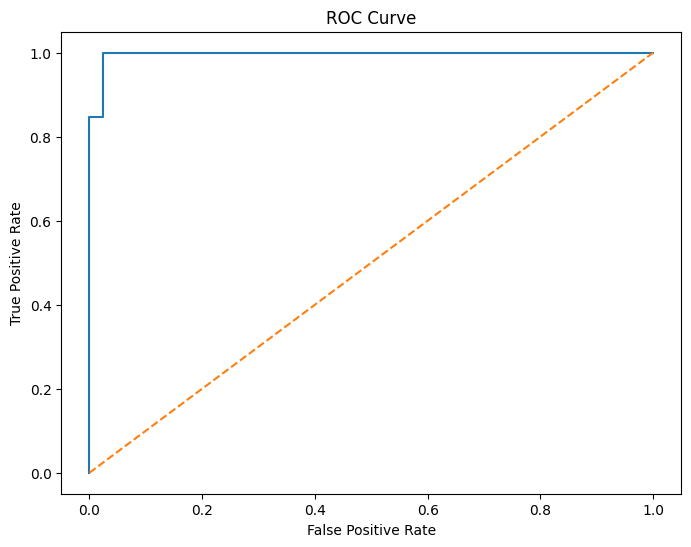

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_scores
)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [15]:
import numpy as np

best_threshold = thresholds[np.argmax(tpr - fpr)]

print("Best Threshold =", best_threshold)

Best Threshold = 0.3079652528280608


In [16]:
from sklearn.metrics import confusion_matrix

y_pred = (y_scores >= best_threshold).astype(int)

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[41  1]
 [ 0 72]]


In [17]:
from sklearn.metrics import precision_score, recall_score

print("Precision =", precision_score(y_test, y_pred))
print("Recall =", recall_score(y_test, y_pred))

Precision = 0.9863013698630136
Recall = 1.0
